# 🎮 Analyse des prédictions de victoires Pokémon

**Défi quotidien — Statistiques pour le Machine Learning**

Ce notebook couvre l'ensemble du pipeline demandé :

1. **Préparation des données** — chargement, nettoyage des valeurs manquantes, calcul du pourcentage de victoires
2. **Analyse exploratoire (EDA)** — matrice de corrélation, pair plot, top 10 des Pokémon
3. **Machine Learning** — régression linéaire, forêt aléatoire et XGBoost pour prédire le taux de victoire, comparés via la MAE

> 💡 *Astuce Colab :* si vous exécutez ce notebook sur Google Colab, téléversez `pokemon.csv` et `combats.csv` (menu Fichiers à gauche) ou montez votre Google Drive avant de lancer les cellules.


## 0. Importation des bibliothèques

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

print("Bibliothèques importées ✅")

Bibliothèques importées ✅


## 1. Préparation des données

### 1.1 Chargement des fichiers

In [2]:
pokemon = pd.read_csv("pokemon.csv")
combats = pd.read_csv("combats.csv")

print("pokemon.csv :", pokemon.shape)
print("combats.csv :", combats.shape)
pokemon.head()

pokemon.csv : (800, 12)
combats.csv : (50000, 3)


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


In [3]:
combats.head()

,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


### 1.2 Aperçu des valeurs manquantes

In [4]:
print("Valeurs manquantes dans pokemon.csv :")
print(pokemon.isnull().sum())

Valeurs manquantes dans pokemon.csv :
#               0
Name            1
Type 1          0
Type 2        386
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64


### 1.3 Correction des valeurs manquantes

**Nom manquant** — le Pokémon situé à l'index 62 (n° 63, de type `Fighting`) est **Primeape**.
Ses statistiques (Attack 105, Speed 95, évolution de Mankey n° 62) confirment l'identification.


In [5]:
# Identifier la ligne dont le nom est manquant
missing = pokemon[pokemon["Name"].isnull()]
print("Ligne sans nom :")
print(missing[["#", "Name", "Type 1", "Attack", "Speed"]])

# Compléter le nom manquant (Primeape)
pokemon.loc[pokemon["Name"].isnull(), "Name"] = "Primeape"

print("\nAprès correction :")
print(pokemon.loc[pokemon["#"] == 63, ["#", "Name", "Type 1"]])

Ligne sans nom :
     # Name    Type 1  Attack  Speed
62  63  NaN  Fighting     105     95

Après correction :
     #      Name    Type 1
62  63  Primeape  Fighting


**Type 2 manquant** — de nombreux Pokémon n'ont qu'un seul type.
On remplace les `NaN` par la catégorie explicite `"None"` (Aucun).


In [6]:
pokemon["Type 2"] = pokemon["Type 2"].fillna("None")

print("Valeurs manquantes restantes :")
print(pokemon.isnull().sum().sum(), "au total")
pokemon.head()

Valeurs manquantes restantes :
0 au total


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,None,39,52,43,60,50,65,1,False


### 1.4 Calcul du pourcentage de victoires

Chaque combat oppose deux Pokémon (`First_pokemon`, `Second_pokemon`) et enregistre le `Winner`.
Pour chaque Pokémon on calcule :

$$\text{Win \%} = \frac{\text{nombre de victoires}}{\text{nombre total de combats}} \times 100$$


In [7]:
# Nombre de combats disputés par chaque Pokémon (en 1re ou 2e position)
total_as_first = combats["First_pokemon"].value_counts()
total_as_second = combats["Second_pokemon"].value_counts()
total_battles = total_as_first.add(total_as_second, fill_value=0)

# Nombre de victoires
wins = combats["Winner"].value_counts()

# Assemblage dans un DataFrame
win_stats = pd.DataFrame({
    "total_battles": total_battles,
    "wins": wins
}).fillna(0)

win_stats["win_pct"] = (win_stats["wins"] / win_stats["total_battles"]) * 100
win_stats.index.name = "#"
win_stats = win_stats.reset_index()

print("Pokémon avec statistiques de combat :", win_stats.shape[0])
win_stats.sort_values("win_pct", ascending=False).head()

Pokémon avec statistiques de combat : 784


,#,total_battles,wins,win_pct
147,155,129,127.0,98.449612
500,513,119,116.0,97.478992
688,704,125,121.0,96.800000
18,20,119,115.0,96.638655
146,154,141,136.0,96.453901


### 1.5 Fusion des deux jeux de données

In [8]:
df = pokemon.merge(win_stats, on="#", how="inner")

# Certains Pokémon (#) n'apparaissent dans aucun combat -> on garde uniquement ceux qui ont des combats
print("Pokémon après fusion :", df.shape[0])
print("Pokémon sans aucun combat (exclus) :", pokemon.shape[0] - df.shape[0])

df[["#", "Name", "Type 1", "Type 2", "HP", "Attack", "Speed", "win_pct"]].head()

Pokémon après fusion : 784
Pokémon sans aucun combat (exclus) : 16


,#,Name,Type 1,Type 2,HP,Attack,Speed,win_pct
0,1,Bulbasaur,Grass,Poison,45,49,45,27.819549
1,2,Ivysaur,Grass,Poison,60,62,60,38.016529
2,3,Venusaur,Grass,Poison,80,82,80,67.424242
3,4,Mega Venusaur,Grass,Poison,80,100,80,56.000000
4,5,Charmander,Fire,None,39,52,65,49.107143


## 2. Analyse exploratoire et visualisation

### 2.1 Distribution du pourcentage de victoires

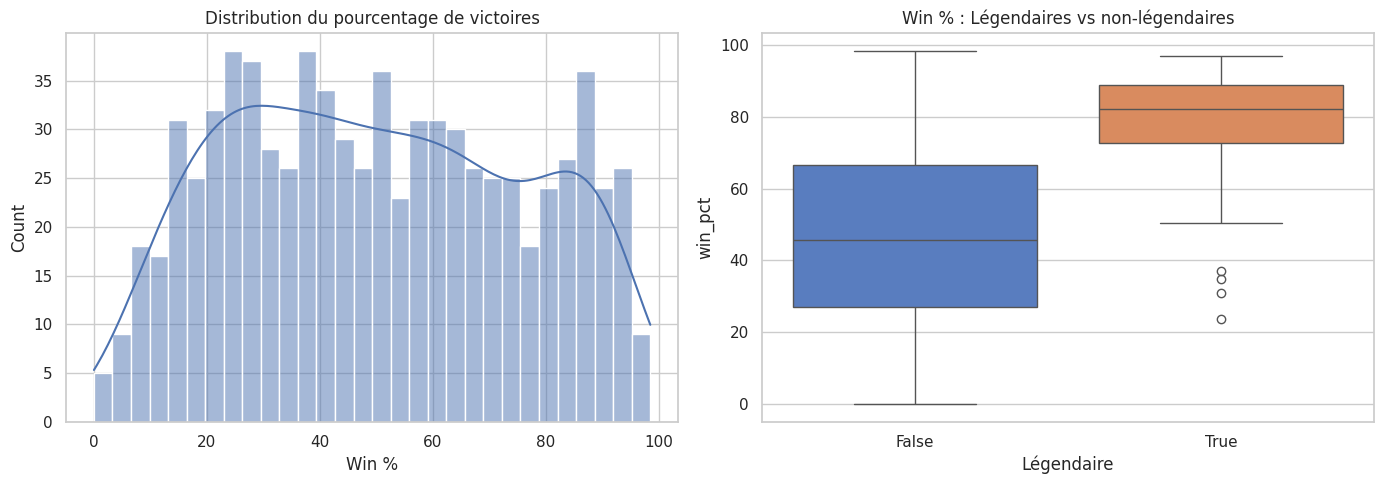

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["win_pct"], bins=30, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution du pourcentage de victoires")
axes[0].set_xlabel("Win %")

sns.boxplot(x=df["Legendary"], y=df["win_pct"], ax=axes[1], hue=df["Legendary"], legend=False)
axes[1].set_title("Win % : Légendaires vs non-légendaires")
axes[1].set_xlabel("Légendaire")
plt.tight_layout()
plt.show()

### 2.2 Matrice de corrélation

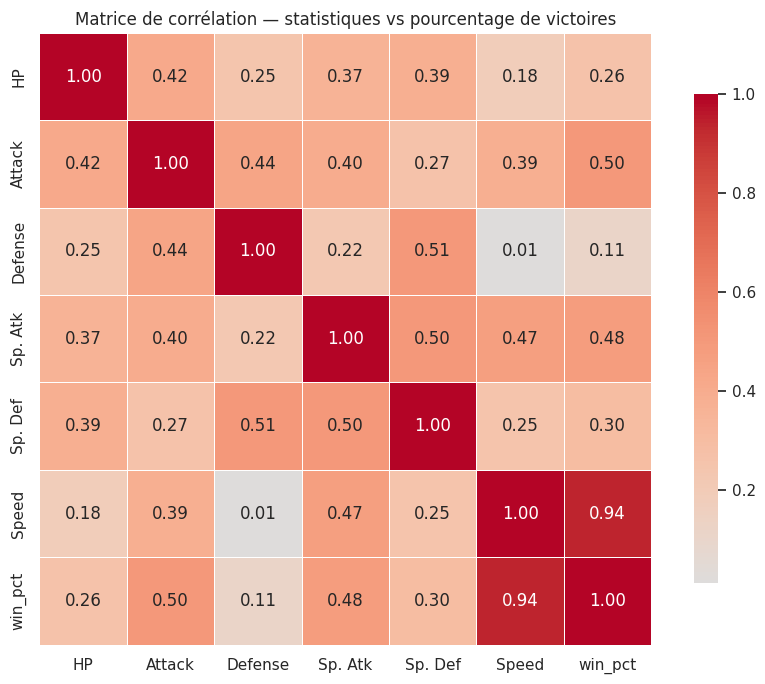

Corrélation de chaque statistique avec le win % :
Speed      0.938055
Attack     0.502825
Sp. Atk    0.481445
Sp. Def    0.302422
HP         0.261602
Defense    0.114565
Name: win_pct, dtype: float64


In [10]:
stat_cols = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed", "win_pct"]
corr = df[stat_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Matrice de corrélation — statistiques vs pourcentage de victoires")
plt.tight_layout()
plt.show()

print("Corrélation de chaque statistique avec le win % :")
print(corr["win_pct"].drop("win_pct").sort_values(ascending=False))

> **Observation :** la **Vitesse (Speed)** est de loin la statistique la plus corrélée au taux de victoire —
> logique, car dans les combats Pokémon le plus rapide attaque en premier.


### 2.3 Pair plot Seaborn (statistiques clés vs win %)

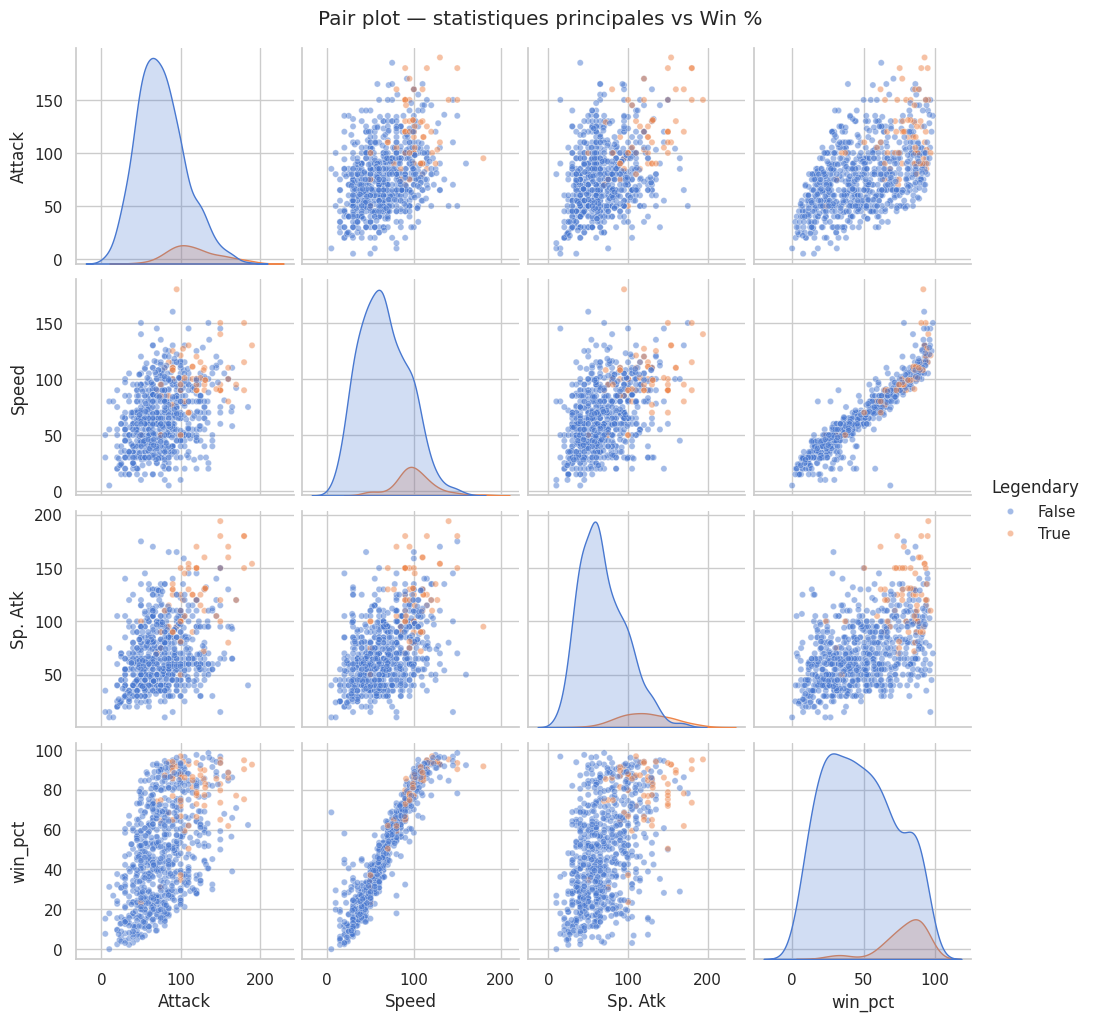

In [11]:
# On sélectionne les statistiques les plus pertinentes pour rester lisible
pair_cols = ["Attack", "Speed", "Sp. Atk", "win_pct"]
g = sns.pairplot(df[pair_cols + ["Legendary"]], hue="Legendary",
                 diag_kind="kde", plot_kws={"alpha": 0.5, "s": 20})
g.figure.suptitle("Pair plot — statistiques principales vs Win %", y=1.02)
plt.show()

### 2.4 PairGrid personnalisé (Speed / Attack vs Win %)

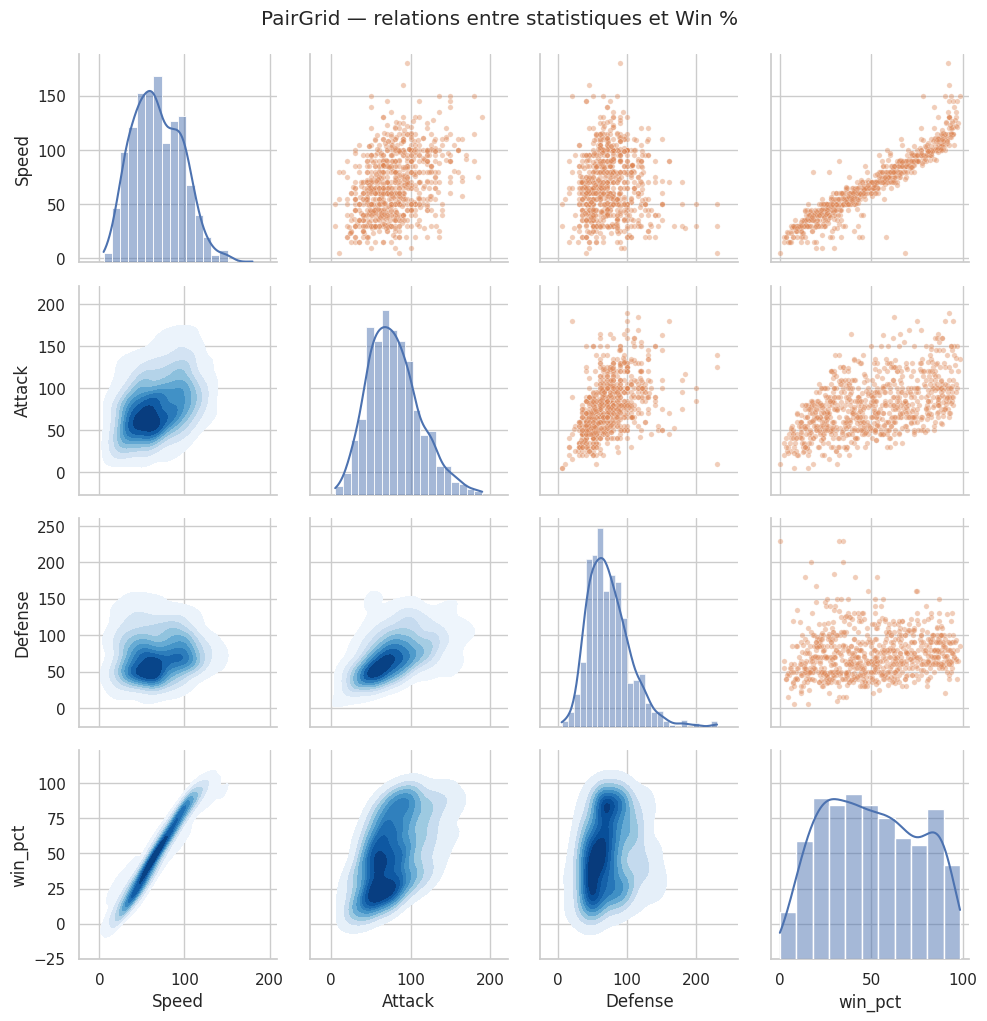

In [12]:
grid_cols = ["Speed", "Attack", "Defense", "win_pct"]
g = sns.PairGrid(df[grid_cols])
g.map_upper(sns.scatterplot, alpha=0.4, s=15, color="#DD8452")
g.map_lower(sns.kdeplot, cmap="Blues", fill=True)
g.map_diag(sns.histplot, kde=True, color="#4C72B0")
g.figure.suptitle("PairGrid — relations entre statistiques et Win %", y=1.02)
plt.show()

### 2.5 Top 10 des Pokémon par pourcentage de victoires

In [13]:
top10 = df.sort_values("win_pct", ascending=False).head(10)

print("🏆 Top 10 des Pokémon par taux de victoire :")
display_cols = ["Name", "Type 1", "Type 2", "HP", "Attack", "Speed",
                "total_battles", "win_pct"]
top10[display_cols].reset_index(drop=True)

🏆 Top 10 des Pokémon par taux de victoire :


,Name,Type 1,Type 2,HP,Attack,Speed,total_battles,win_pct
0,Mega Aerodactyl,Rock,Flying,80,135,150,129,98.449612
1,Weavile,Dark,Ice,70,120,125,119,97.478992
2,Tornadus Therian Forme,Flying,None,79,100,121,125,96.800000
3,Mega Beedrill,Bug,Poison,65,150,145,119,96.638655
4,Aerodactyl,Rock,Flying,80,105,130,141,96.453901
5,Mega Lopunny,Normal,Fighting,65,136,135,129,96.124031
6,Greninja,Water,Dark,72,95,122,127,96.062992
7,Meloetta Pirouette Forme,Normal,Fighting,100,128,128,123,95.934959
8,Mega Mewtwo Y,Psychic,None,106,150,140,125,95.200000
9,Mega Sharpedo,Water,Dark,70,140,105,120,95.000000


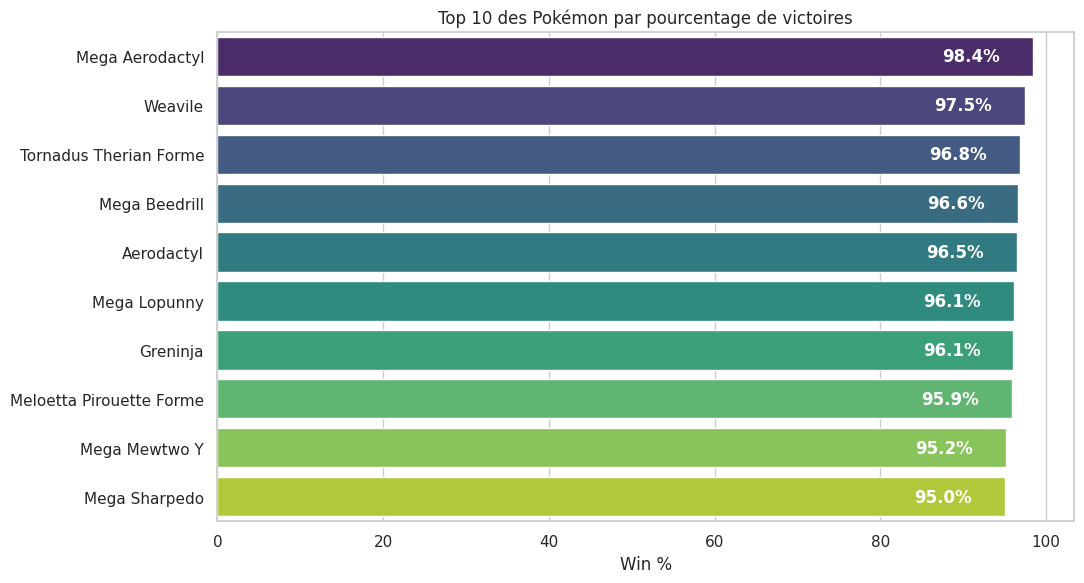

In [14]:
plt.figure(figsize=(11, 6))
sns.barplot(data=top10, y="Name", x="win_pct", hue="Name", legend=False, palette="viridis")
plt.title("Top 10 des Pokémon par pourcentage de victoires")
plt.xlabel("Win %")
plt.ylabel("")
for i, (_, row) in enumerate(top10.iterrows()):
    plt.text(row["win_pct"] - 4, i, f"{row['win_pct']:.1f}%",
             va="center", ha="right", color="white", fontweight="bold")
plt.tight_layout()
plt.show()

> Les meilleurs combattants combinent une **vitesse élevée** et une **forte attaque**
> (Mega-évolutions et légendaires apparaissent fréquemment dans ce top 10).


## 3. Machine Learning — prédiction du pourcentage de victoires

### 3.1 Préparation des caractéristiques (features)

On utilise les 6 statistiques de base + la vitesse totale. La cible est `win_pct`.


In [15]:
feature_cols = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]

X = df[feature_cols].copy()
y = df["win_pct"].copy()

print("X :", X.shape, "| y :", y.shape)
X.head()

X : (784, 6) | y : (784,)


,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
0,45,49,49,65,65,45
1,60,62,63,80,80,60
2,80,82,83,100,100,80
3,80,100,123,122,120,80
4,39,52,43,60,50,65


### 3.2 Découpage entraînement / test (80/20)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Mise à l'échelle (utile pour la régression linéaire ; sans effet négatif sur les arbres)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Entraînement :", X_train.shape[0], "| Test :", X_test.shape[0])

Entraînement : 627 | Test : 157


### 3.3 Entraînement et évaluation des 3 modèles

In [17]:
results = {}

# --- 1. Régression linéaire ---
lin = LinearRegression()
lin.fit(X_train_scaled, y_train)
pred_lin = lin.predict(X_test_scaled)
results["Régression linéaire"] = {
    "MAE": mean_absolute_error(y_test, pred_lin),
    "R2": r2_score(y_test, pred_lin),
    "pred": pred_lin,
}

# --- 2. Forêt aléatoire ---
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)          # les arbres n'ont pas besoin de scaling
pred_rf = rf.predict(X_test)
results["Forêt aléatoire"] = {
    "MAE": mean_absolute_error(y_test, pred_rf),
    "R2": r2_score(y_test, pred_rf),
    "pred": pred_rf,
}

# --- 3. XGBoost ---
xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                   subsample=0.9, colsample_bytree=0.9, random_state=42)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)
results["XGBoost"] = {
    "MAE": mean_absolute_error(y_test, pred_xgb),
    "R2": r2_score(y_test, pred_xgb),
    "pred": pred_xgb,
}

for name, r in results.items():
    print(f"{name:22s} | MAE = {r['MAE']:.3f} | R² = {r['R2']:.3f}")

Régression linéaire    | MAE = 6.153 | R² = 0.873
Forêt aléatoire        | MAE = 4.404 | R² = 0.939
XGBoost                | MAE = 4.426 | R² = 0.943


### 3.4 Comparaison des modèles par MAE

             Modèle      MAE       R2
    Forêt aléatoire 4.403605 0.938898
            XGBoost 4.426400 0.942743
Régression linéaire 6.153125 0.872818


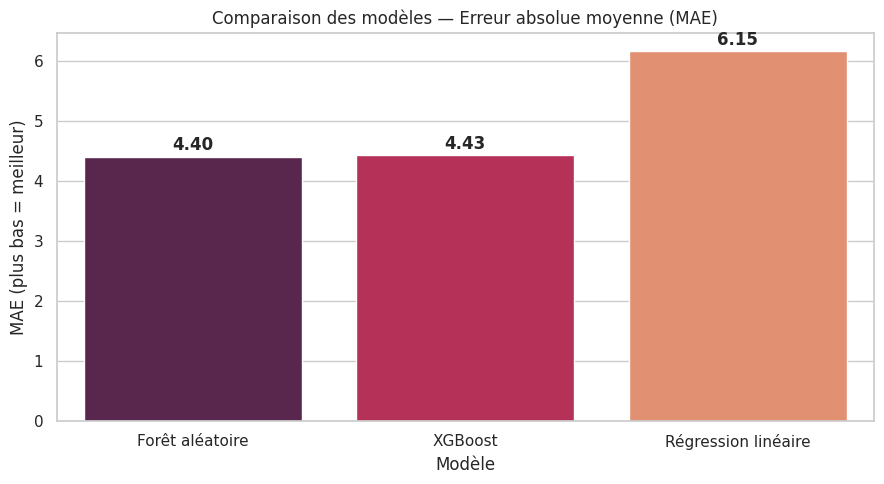


🥇 Meilleur modèle : Forêt aléatoire (MAE = 4.404)


In [18]:
comparison = pd.DataFrame({
    "Modèle": list(results.keys()),
    "MAE": [r["MAE"] for r in results.values()],
    "R2": [r["R2"] for r in results.values()],
}).sort_values("MAE")

print(comparison.to_string(index=False))

plt.figure(figsize=(9, 5))
bars = sns.barplot(data=comparison, x="Modèle", y="MAE", hue="Modèle",
                   legend=False, palette="rocket")
plt.title("Comparaison des modèles — Erreur absolue moyenne (MAE)")
plt.ylabel("MAE (plus bas = meilleur)")
for i, v in enumerate(comparison["MAE"]):
    plt.text(i, v + 0.1, f"{v:.2f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

best = comparison.iloc[0]
print(f"\n🥇 Meilleur modèle : {best['Modèle']} (MAE = {best['MAE']:.3f})")

### 3.5 Prédictions vs valeurs réelles (meilleur modèle)

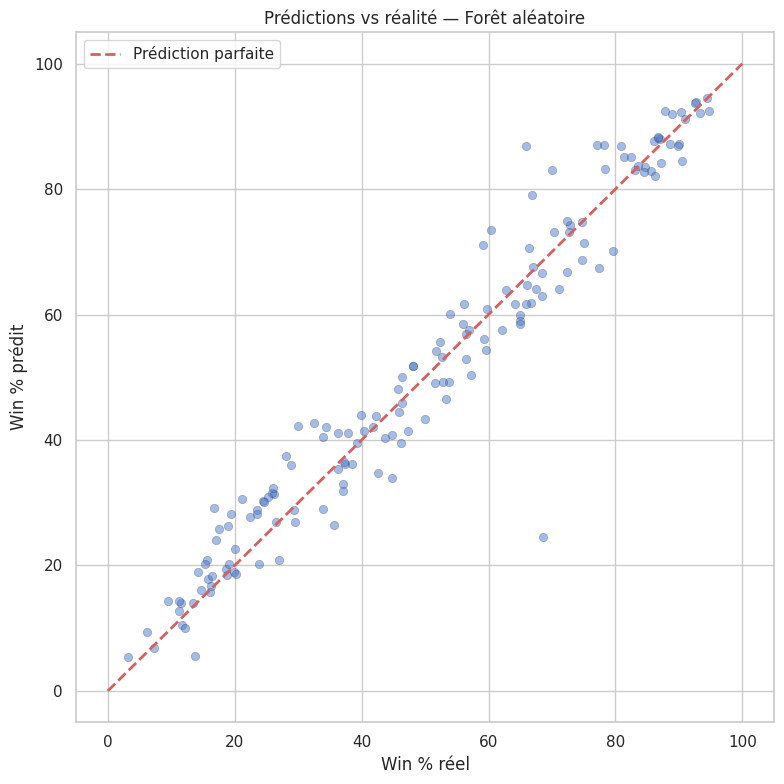

In [19]:
best_name = comparison.iloc[0]["Modèle"]
best_pred = results[best_name]["pred"]

plt.figure(figsize=(8, 8))
plt.scatter(y_test, best_pred, alpha=0.5, edgecolor="k", linewidth=0.3)
lims = [0, 100]
plt.plot(lims, lims, "r--", lw=2, label="Prédiction parfaite")
plt.xlabel("Win % réel")
plt.ylabel("Win % prédit")
plt.title(f"Prédictions vs réalité — {best_name}")
plt.legend()
plt.tight_layout()
plt.show()

### 3.6 Importance des caractéristiques

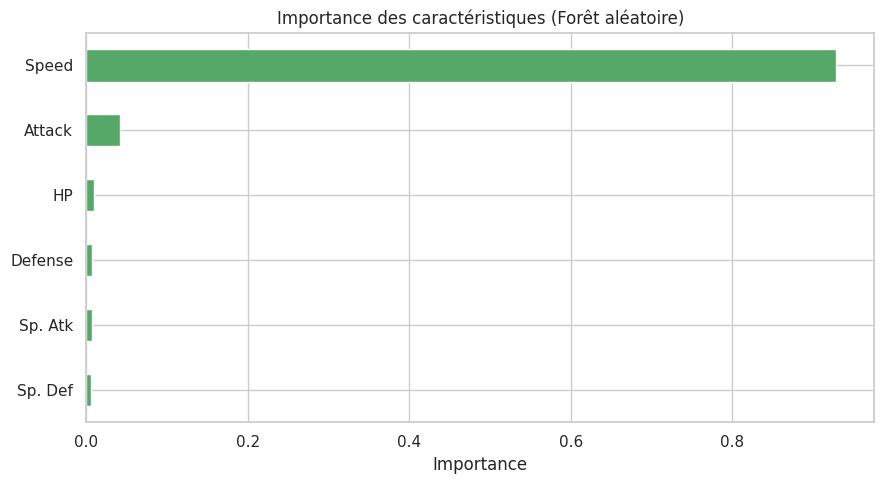

La Vitesse (Speed) domine largement la prédiction du taux de victoire.


In [20]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()

plt.figure(figsize=(9, 5))
importances.plot(kind="barh", color="#55A868")
plt.title("Importance des caractéristiques (Forêt aléatoire)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("La Vitesse (Speed) domine largement la prédiction du taux de victoire.")

## 4. Bonus — Réduction de dimensionnalité par ACP (PCA)

On projette les 6 statistiques sur 2 composantes principales pour visualiser
la structure des données, colorée par le pourcentage de victoires.


Variance expliquée : [0.45300762 0.1831929 ]
Variance cumulée   : 0.6362005262812155


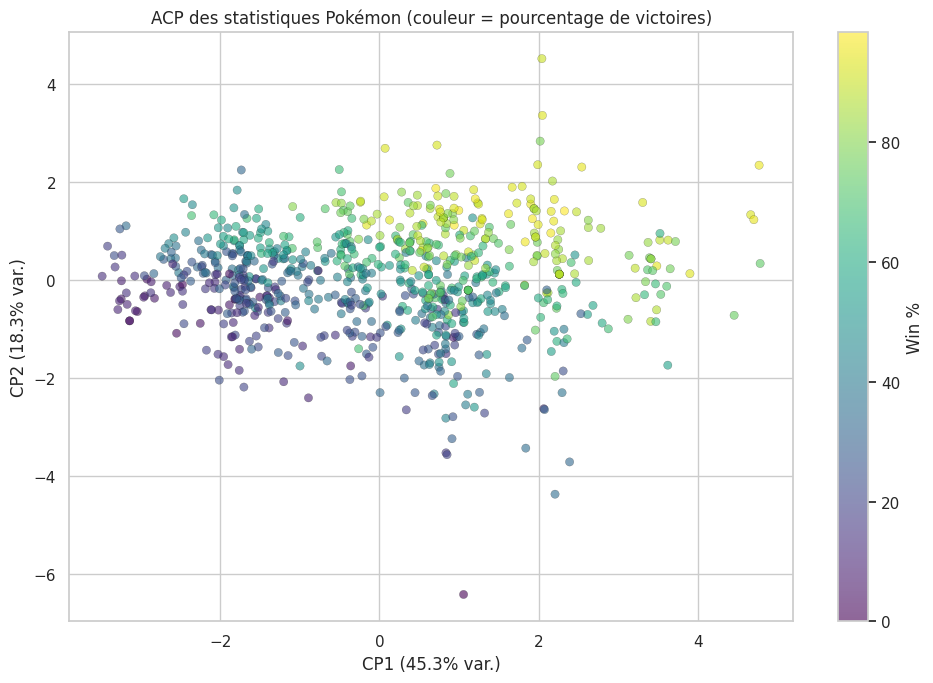

In [21]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(StandardScaler().fit_transform(X))

print("Variance expliquée :", pca.explained_variance_ratio_)
print("Variance cumulée   :", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(10, 7))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="viridis",
                 alpha=0.6, edgecolor="k", linewidth=0.2)
plt.colorbar(sc, label="Win %")
plt.xlabel(f"CP1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)")
plt.ylabel(f"CP2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)")
plt.title("ACP des statistiques Pokémon (couleur = pourcentage de victoires)")
plt.tight_layout()
plt.show()

## 5. Conclusion

**Ce qui a été réalisé :**

- ✅ Nettoyage : nom manquant complété (**Primeape**, n° 63) et `Type 2` manquant → `"None"`
- ✅ Calcul du **pourcentage de victoires** par Pokémon à partir de 50 000 combats
- ✅ EDA : matrice de corrélation, pair plot / PairGrid, top 10 des combattants
- ✅ 3 modèles de régression comparés via la **MAE**
- ✅ Bonus : importance des variables + réduction de dimension par **ACP**

**Enseignement clé :** la **Vitesse** est le prédicteur le plus puissant du succès en combat —
attaquer en premier est décisif. Les modèles à base d'arbres (Forêt aléatoire, XGBoost)
surpassent la régression linéaire car la relation statistiques → victoire n'est pas parfaitement linéaire.
